In [8]:
%cd /content
!ls /content/

/content
input.jpg  pytorch-CycleGAN-and-pix2pix  sample_data  style.png


In [9]:
from PIL import Image
img = Image.open("/content/input.jpg").convert("RGB")
img = img.resize((512, 512))
img.save("/content/input.jpg")
print("Resized to", img.size)

Resized to (512, 512)


In [10]:
%cd /content
!git clone https://github.com/junyanz/pytorch-CycleGAN-and-pix2pix
%cd /content/pytorch-CycleGAN-and-pix2pix
!pip install dominate visdom wandb

/content
fatal: destination path 'pytorch-CycleGAN-and-pix2pix' already exists and is not an empty directory.
/content/pytorch-CycleGAN-and-pix2pix


In [11]:
!bash ./scripts/download_cyclegan_model.sh style_monet
!ls checkpoints/style_monet_pretrained/

Note: available models are apple2orange, orange2apple, summer2winter_yosemite, winter2summer_yosemite, horse2zebra, zebra2horse, monet2photo, style_monet, style_cezanne, style_ukiyoe, style_vangogh, sat2map, map2sat, cityscapes_photo2label, cityscapes_label2photo, facades_photo2label, facades_label2photo, iphone2dslr_flower
Specified [style_monet]
for details.

--2026-10-03 17:25:34--  http://efrosgans.eecs.berkeley.edu/cyclegan/pretrained_models/style_monet.pth
Resolving efrosgans.eecs.berkeley.edu (efrosgans.eecs.berkeley.edu)... 128.32.139.28
Connecting to efrosgans.eecs.berkeley.edu (efrosgans.eecs.berkeley.edu)|128.32.139.28|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 45575747 (43M)
Saving to: ‘./checkpoints/style_monet_pretrained/latest_net_G.pth’

./checkpoints/style 100%[===================>]  43.46M  14.2MB/s    in 3.4s    

2026-10-03 17:25:38 (12.9 MB/s) - ‘./checkpoints/style_monet_pretrained/latest_net_G.pth’ saved [45575747/45575747]

latest_n

In [12]:
!mkdir -p datasets/mytest/testA
!cp /content/input.jpg datasets/mytest/testA/
!python test.py --dataroot datasets/mytest/testA --name style_monet_pretrained --model test --no_dropout
!ls results/style_monet_pretrained/test_latest/images/

----------------- Options ---------------
             aspect_ratio: 1.0                           
               batch_size: 1                             
          checkpoints_dir: ./checkpoints                 
                crop_size: 256                           
                 dataroot: datasets/mytest/testA         	[default: None]
             dataset_mode: single                        
                direction: AtoB                          
          display_winsize: 256                           
                    epoch: latest                        
                     eval: False                         
                init_gain: 0.02                          
                init_type: normal                        
                 input_nc: 3                             
                  isTrain: False                         	[default: None]
                load_iter: 0                             	[default: 0]
                load_size: 256             

In [13]:
import torch, torch.optim as optim
from torchvision import models, transforms
from torchvision.utils import save_image
from PIL import Image

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
size = 512

loader = transforms.Compose([transforms.Resize((size, size)), transforms.ToTensor()])
def load(path): return loader(Image.open(path).convert("RGB")).unsqueeze(0).to(device)

content = load("/content/input.jpg")
style = load("/content/style.png")

vgg = models.vgg19(weights=models.VGG19_Weights.DEFAULT).features.to(device).eval()
for p in vgg.parameters(): p.requires_grad_(False)

mean = torch.tensor([0.485, 0.456, 0.406]).view(-1,1,1).to(device)
std  = torch.tensor([0.229, 0.224, 0.225]).view(-1,1,1).to(device)
norm = lambda x: (x - mean) / std

content_layers = {'21'}
style_layers = {'0','5','10','19','28'}

def features(x):
    feats, x = {}, norm(x)
    for name, layer in vgg._modules.items():
        x = layer(x)
        if name in content_layers | style_layers: feats[name] = x
    return feats

def gram(t):
    b, c, h, w = t.size()
    f = t.view(c, h*w)
    return f @ f.t() / (c*h*w)

cf = features(content)
sf = features(style)
style_grams = {l: gram(sf[l]) for l in style_layers}

target = content.clone().requires_grad_(True)
opt = optim.Adam([target], lr=0.02)
style_weight, content_weight = 1e6, 1

for i in range(1, 501):
    opt.zero_grad()
    tf = features(target)
    c_loss = torch.mean((tf['21'] - cf['21'])**2)
    s_loss = sum(torch.mean((gram(tf[l]) - style_grams[l])**2) for l in style_layers)
    loss = content_weight*c_loss + style_weight*s_loss
    loss.backward()
    opt.step()
    target.data.clamp_(0, 1)
    if i % 100 == 0: print(i, loss.item())

save_image(target, "/content/nst_output.png")
print("Saved!")

Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to /root/.cache/torch/hub/checkpoints/vgg19-dcbb9e9d.pth


100%|██████████| 548M/548M [00:09<00:00, 63.0MB/s]


100 11.68870735168457
200 9.179823875427246
300 8.637774467468262
400 8.13232707977295
500 7.701478004455566
Saved!


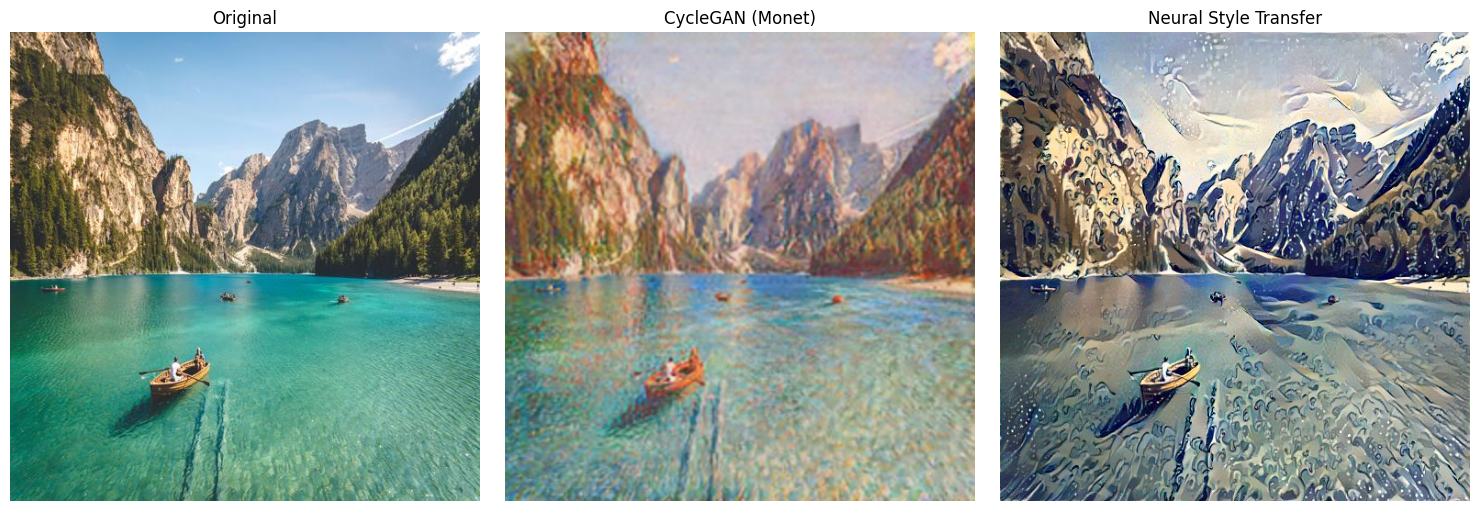

In [14]:
import matplotlib.pyplot as plt
import glob
from PIL import Image

cyc = glob.glob("/content/pytorch-CycleGAN-and-pix2pix/results/style_monet_pretrained/test_latest/images/*_fake.png")[0]

imgs = [("Original", "/content/input.jpg"),
        ("CycleGAN (Monet)", cyc),
        ("Neural Style Transfer", "/content/nst_output.png")]

fig, ax = plt.subplots(1, 3, figsize=(15, 5))
for a, (title, path) in zip(ax, imgs):
    a.imshow(Image.open(path).convert("RGB").resize((512, 512)))
    a.set_title(title); a.axis("off")
plt.tight_layout()
plt.savefig("/content/comparison.png", dpi=200)
plt.show()